<a href="https://colab.research.google.com/github/kollivarshini7625-cpu/IT-IGNITE/blob/main/iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


In [ ]:
iris_raw = load_iris()
df_iris = pd.DataFrame(iris_raw.data, columns=['sepal_length','sepal_width','petal_length','petal_width'])
df_iris['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)
print("Shape:", df_iris.shape)
print("\nClass distribution:")
print(df_iris['species'].value_counts())
df_iris.head()

Shape: (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df_iris.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


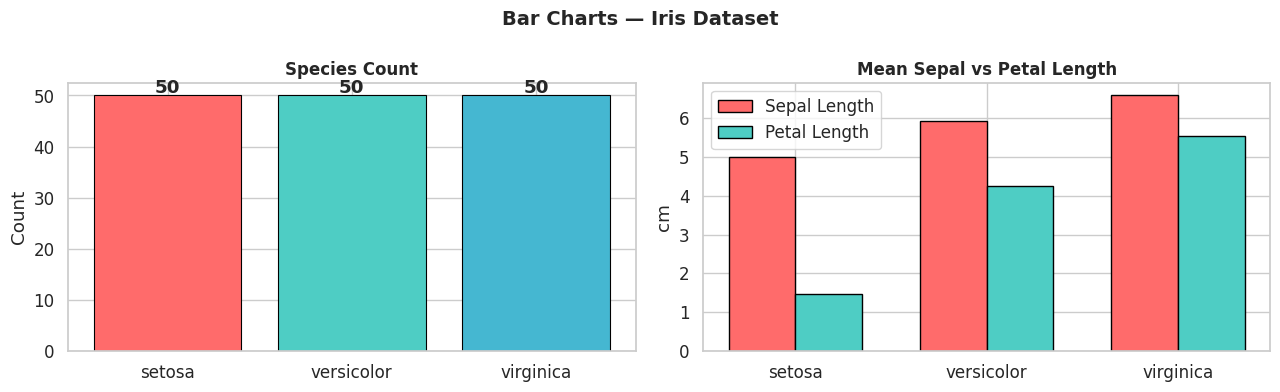


📌 Insight: Virginica has the longest petals; Setosa has the shortest.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#FF6B6B','#4ECDC4','#45B7D1']

counts = df_iris['species'].value_counts()
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Species Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, str(v), ha='center', fontweight='bold')

mean_vals = df_iris.groupby('species')[['sepal_length','petal_length']].mean()
x = np.arange(3); w = 0.35
axes[1].bar(x - w/2, mean_vals['sepal_length'], w, label='Sepal Length', color='#FF6B6B', edgecolor='black')
axes[1].bar(x + w/2, mean_vals['petal_length'], w, label='Petal Length', color='#4ECDC4', edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(mean_vals.index)
axes[1].set_title('Mean Sepal vs Petal Length', fontsize=12, fontweight='bold')
axes[1].set_ylabel('cm'); axes[1].legend()

plt.suptitle('Bar Charts — Iris Dataset', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("\n📌 Insight: Virginica has the longest petals; Setosa has the shortest.")


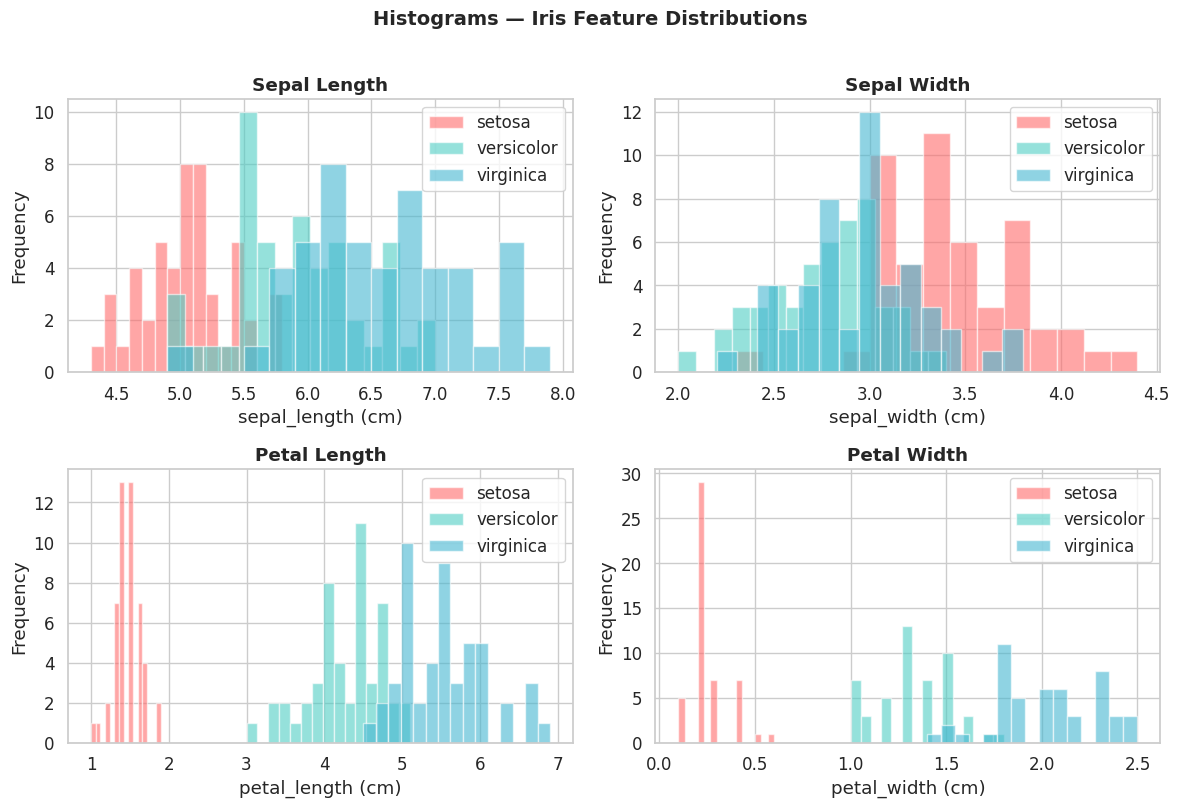


📌 Insight: Petal length shows 3 distinct clusters — perfect for ML classification!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length','sepal_width','petal_length','petal_width']
colors_map = {'setosa':'#FF6B6B','versicolor':'#4ECDC4','virginica':'#45B7D1'}

for ax, feat in zip(axes.flatten(), features):
    for species, grp in df_iris.groupby('species'):
        ax.hist(grp[feat], bins=15, alpha=0.6, label=species, color=colors_map[species], edgecolor='white')
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel(feat + ' (cm)'); ax.set_ylabel('Frequency'); ax.legend()

plt.suptitle('Histograms — Iris Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print("\n📌 Insight: Petal length shows 3 distinct clusters — perfect for ML classification!")


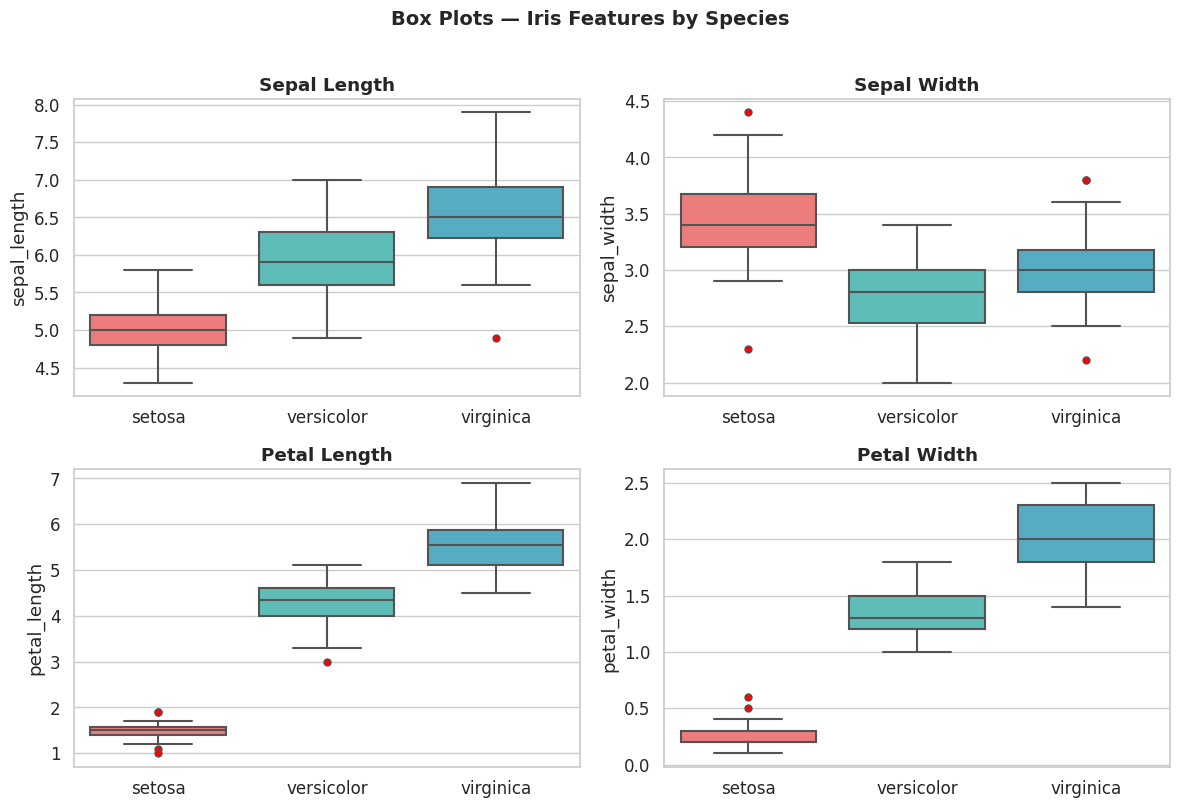


📌 Insight: Sepal width has outliers in setosa. Petal features show clean separation.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
pal = {'setosa':'#FF6B6B','versicolor':'#4ECDC4','virginica':'#45B7D1'}

for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(data=df_iris, x='species', y=feat, palette=pal, ax=ax, linewidth=1.5,
                flierprops=dict(marker='o', markerfacecolor='red', markersize=5))
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold'); ax.set_xlabel('')

plt.suptitle('Box Plots — Iris Features by Species', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print("\n📌 Insight: Sepal width has outliers in setosa. Petal features show clean separation.")

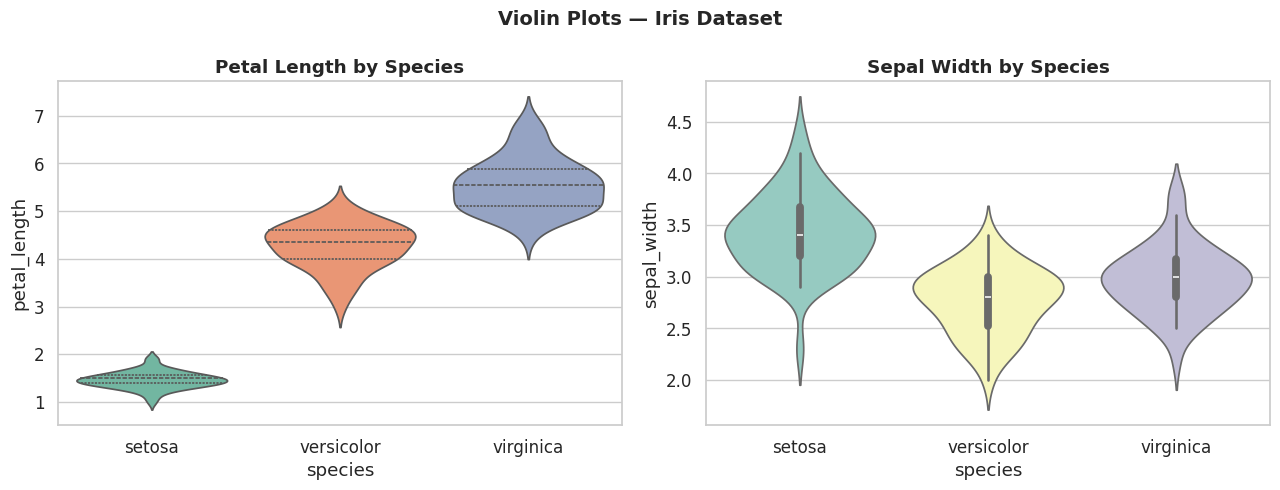


📌 Insight: Virginica petal_length is widely spread; Setosa is very compact and narrow.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.violinplot(data=df_iris, x='species', y='petal_length', palette='Set2', inner='quartile', ax=axes[0])
axes[0].set_title('Petal Length by Species', fontweight='bold')

sns.violinplot(data=df_iris, x='species', y='sepal_width', palette='Set3', inner='box', ax=axes[1])
axes[1].set_title('Sepal Width by Species', fontweight='bold')

plt.suptitle('Violin Plots — Iris Dataset', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("\n📌 Insight: Virginica petal_length is widely spread; Setosa is very compact and narrow.")

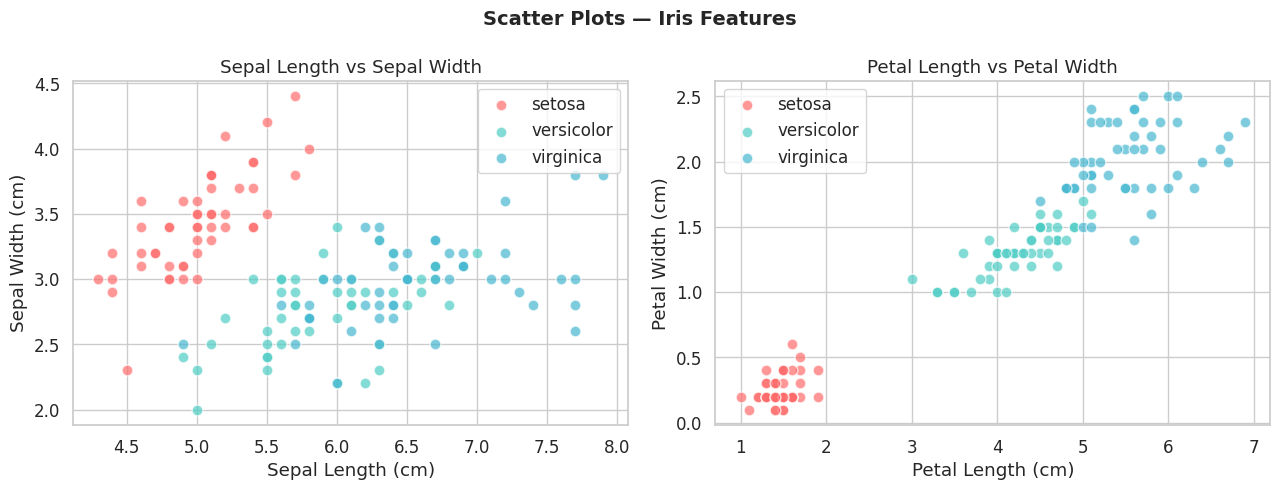


📌 Insight: Petal scatter shows PERFECT 3-way separation — ideal for ML!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = {'setosa':'#FF6B6B','versicolor':'#4ECDC4','virginica':'#45B7D1'}
for sp, grp in df_iris.groupby('species'):
    axes[0].scatter(grp['sepal_length'], grp['sepal_width'], c=cmap[sp], label=sp, alpha=0.7, s=60, edgecolors='white')
    axes[1].scatter(grp['petal_length'], grp['petal_width'], c=cmap[sp], label=sp, alpha=0.7, s=60, edgecolors='white')

axes[0].set(title='Sepal Length vs Sepal Width', xlabel='Sepal Length (cm)', ylabel='Sepal Width (cm)')
axes[1].set(title='Petal Length vs Petal Width', xlabel='Petal Length (cm)', ylabel='Petal Width (cm)')
for ax in axes: ax.legend()
plt.suptitle('Scatter Plots — Iris Features', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("\n📌 Insight: Petal scatter shows PERFECT 3-way separation — ideal for ML!")


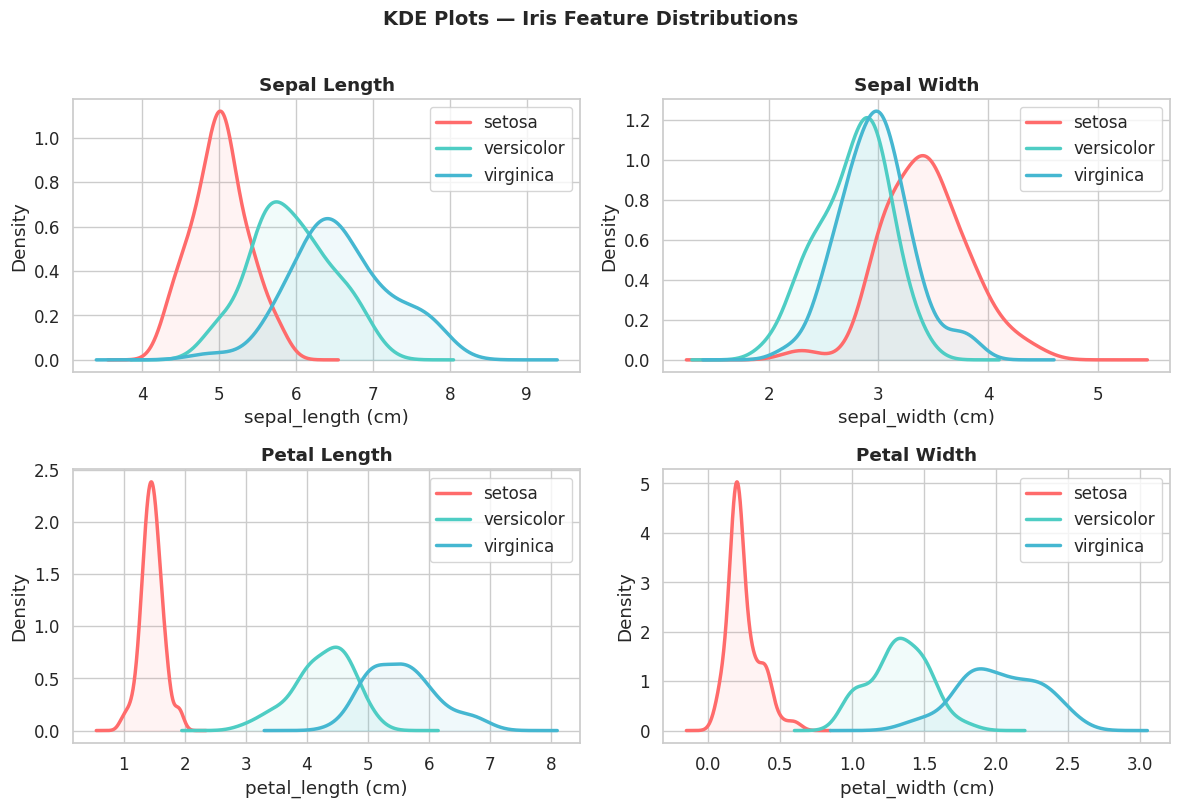


📌 Insight: Setosa is clearly separated on all petal features — easiest class to predict!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['#FF6B6B','#4ECDC4','#45B7D1']

for ax, feat in zip(axes.flatten(), features):
    for sp, col in zip(df_iris['species'].unique(), colors):
        subset = df_iris[df_iris['species']==sp][feat]
        subset.plot.kde(ax=ax, label=sp, color=col, linewidth=2.5)
        ax.fill_between(ax.lines[-1].get_xdata(), ax.lines[-1].get_ydata(), alpha=0.08, color=col)
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel(feat + ' (cm)'); ax.legend()

plt.suptitle('KDE Plots — Iris Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print("\n📌 Insight: Setosa is clearly separated on all petal features — easiest class to predict!")


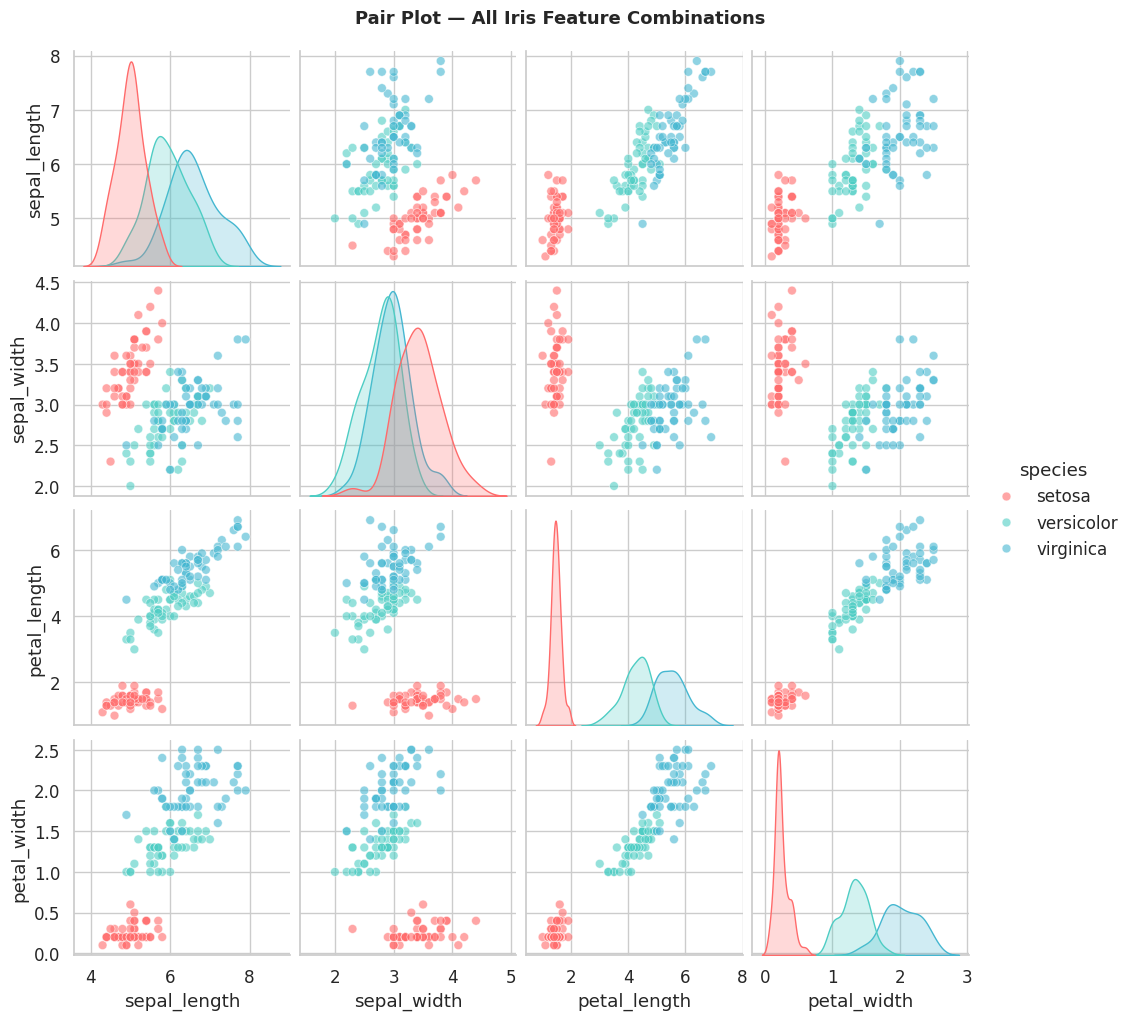


📌 Insight: Petal length vs petal width (bottom-right) is the best pair for classification.


In [ ]:
g = sns.pairplot(df_iris, hue='species',
                 palette={'setosa':'#FF6B6B','versicolor':'#4ECDC4','virginica':'#45B7D1'},
                 diag_kind='kde', plot_kws={'alpha':0.6, 's':40})
g.figure.suptitle('Pair Plot — All Iris Feature Combinations', y=1.02, fontsize=13, fontweight='bold')
plt.show()
print("\n📌 Insight: Petal length vs petal width (bottom-right) is the best pair for classification.")

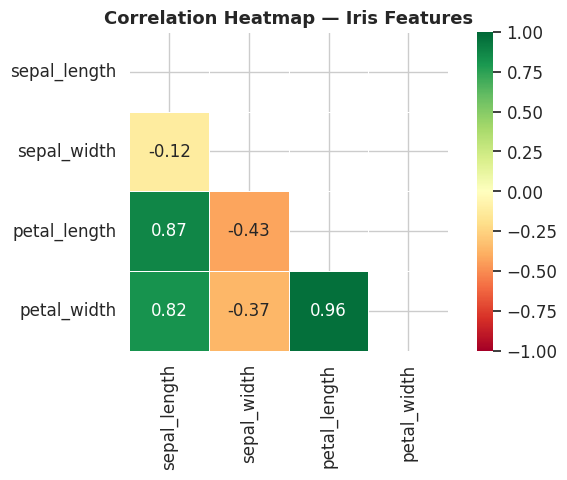


📌 Insight: Petal length & petal width are 96% correlated — nearly redundant features!


In [ ]:
plt.figure(figsize=(7, 5))
corr = df_iris[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            linewidths=0.5, square=True, vmin=-1, vmax=1, annot_kws={'size':12})
plt.title('Correlation Heatmap — Iris Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print("\n📌 Insight: Petal length & petal width are 96% correlated — nearly redundant features!")


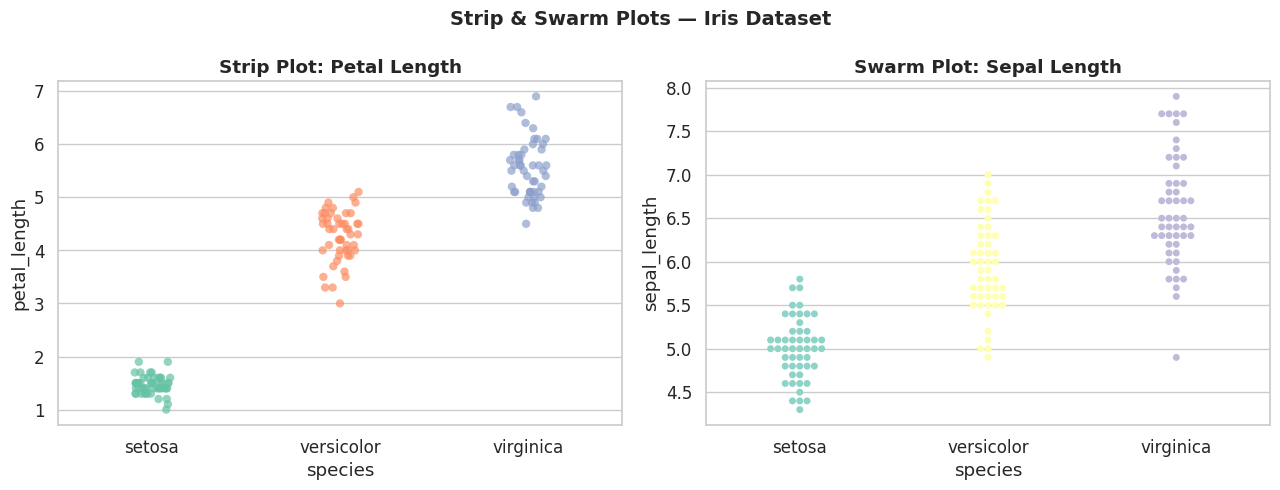


📌 Insight: Each dot = 1 flower. Swarm shows density without binning — 150 points visible!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.stripplot(data=df_iris, x='species', y='petal_length', palette='Set2', jitter=True, ax=axes[0], size=6, alpha=0.7)
axes[0].set_title('Strip Plot: Petal Length', fontweight='bold')

sns.swarmplot(data=df_iris, x='species', y='sepal_length', palette='Set3', ax=axes[1], size=5)
axes[1].set_title('Swarm Plot: Sepal Length', fontweight='bold')

plt.suptitle('Strip & Swarm Plots — Iris Dataset', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("\n📌 Insight: Each dot = 1 flower. Swarm shows density without binning — 150 points visible!")


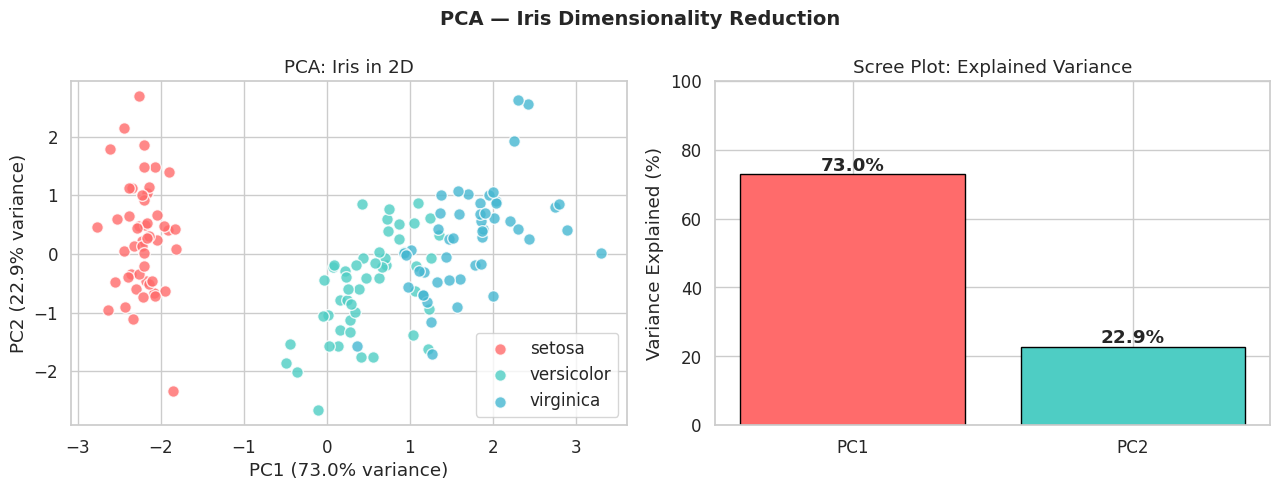


📌 Insight: 2 PCA components capture 95.8% of total variance!


In [ ]:
scaler = StandardScaler()
X_iris = scaler.fit_transform(df_iris[features])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)
df_iris_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_iris_pca['species'] = df_iris['species'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = {'setosa':'#FF6B6B','versicolor':'#4ECDC4','virginica':'#45B7D1'}
for sp, col in cmap.items():
    sub = df_iris_pca[df_iris_pca['species']==sp]
    axes[0].scatter(sub['PC1'], sub['PC2'], c=col, label=sp, s=70, alpha=0.8, edgecolors='white')
axes[0].set(title='PCA: Iris in 2D',
            xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
            ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()

axes[1].bar(['PC1','PC2'], pca.explained_variance_ratio_*100, color=['#FF6B6B','#4ECDC4'], edgecolor='black')
axes[1].set(title='Scree Plot: Explained Variance', ylabel='Variance Explained (%)', ylim=(0, 100))
for i, v in enumerate(pca.explained_variance_ratio_*100):
    axes[1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('PCA — Iris Dimensionality Reduction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"\n📌 Insight: 2 PCA components capture {sum(pca.explained_variance_ratio_*100):.1f}% of total variance!")
